In [8]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

## General Feed Forward Network

Epoch 0, Loss: 0.33501681685447693
Epoch 10, Loss: 0.33501681685447693
Epoch 20, Loss: 0.33501681685447693
Epoch 30, Loss: 0.33501681685447693
Epoch 40, Loss: 0.33501681685447693


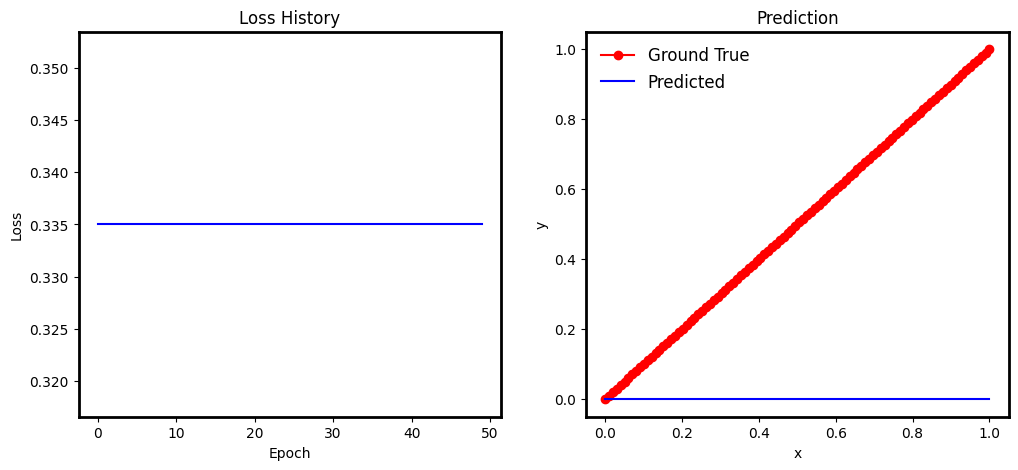

In [9]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.W_xh1 = nn.Linear(1, 1, bias=False)
        self.W_h1h2 = nn.Linear(1, 1, bias=False)
        self.W_h2h3 = nn.Linear(1, 1, bias=False)
        self.W_h3h4 = nn.Linear(1, 1, bias=False)
        self.W_h4y = nn.Linear(1, 1, bias=False)
    
    def forward(self, x):
        h1 = F.relu(self.W_xh1(x))
        h2 = F.relu(self.W_h1h2(h1))
        h3 = F.relu(self.W_h2h3(h2))
        h4 = F.relu(self.W_h3h4(h3))
        y = self.W_h4y(h4)
        return y


x_np =  np.linspace(0, 1, 100)
y_np = np.linspace(0, 1, 100)
x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)

model = SimpleModel()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 50
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = F.mse_loss(y_pred, y)
    loss_history.append(loss.item())
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

with torch.no_grad():
    y_pred = model(x)

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

ax[0].plot(loss_history, color='blue')
ax[0].set_title('Loss History')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[1].plot(x_np, y_np, 'o-', color='red', label = "Ground True")
ax[1].plot(x_np, y_pred.detach().numpy(), 'b-', label = "Predicted")
ax[1].set_title('Prediction')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].legend(frameon=False, fontsize= 12)

for ax in fig.axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.show()

## Residual Connection

Epoch 0, Loss: 0.6472676992416382
Epoch 10, Loss: 0.34156665205955505
Epoch 20, Loss: 0.18348558247089386
Epoch 30, Loss: 0.0929059088230133
Epoch 40, Loss: 0.04314170777797699


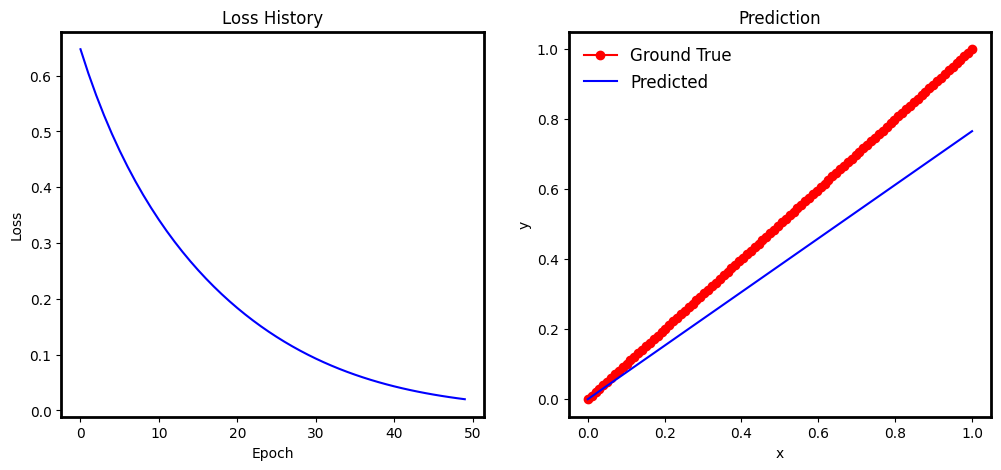

In [10]:
class ResidualModel(nn.Module):
    def __init__(self):
        super(ResidualModel, self).__init__()
        self.W_xh1 = nn.Linear(1, 1, bias=False)
        self.W_h1h2 = nn.Linear(1, 1, bias=False)
        self.W_h2h3 = nn.Linear(1, 1, bias=False)
        self.W_h3h4 = nn.Linear(1, 1, bias=False)
        self.W_h4y = nn.Linear(1, 1, bias=False)
    
    def forward(self, x):
        h1 = F.relu(self.W_xh1(x)) + x
        h2 = F.relu(self.W_h1h2(h1)) + h1
        h3 = F.relu(self.W_h2h3(h2)) + h2
        h4 = F.relu(self.W_h3h4(h3)) + h3
        y = self.W_h4y(h4)
        return y


x_np =  np.linspace(0, 1, 100)
y_np = np.linspace(0, 1, 100)
x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)

model = ResidualModel()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 50
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad();y_pred = model(x);loss = F.mse_loss(y_pred, y);loss_history.append(loss.item());loss.backward();optimizer.step()
    if epoch % 10 == 0: print(f'Epoch {epoch}, Loss: {loss.item()}')

with torch.no_grad(): y_pred = model(x)

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].plot(loss_history, color='blue')
ax[0].set_title('Loss History')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[1].plot(x_np, y_np, 'o-', color='red', label = "Ground True")
ax[1].plot(x_np, y_pred.detach().numpy(), 'b-', label = "Predicted")
ax[1].set_title('Prediction')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].legend(frameon=False, fontsize= 12)

for ax in fig.axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.show()

## Skip Connection (Dense Connection)

Epoch 0, Loss: 0.44183480739593506
Epoch 10, Loss: 0.3780418336391449
Epoch 20, Loss: 0.32275962829589844
Epoch 30, Loss: 0.2749101519584656
Epoch 40, Loss: 0.23356272280216217


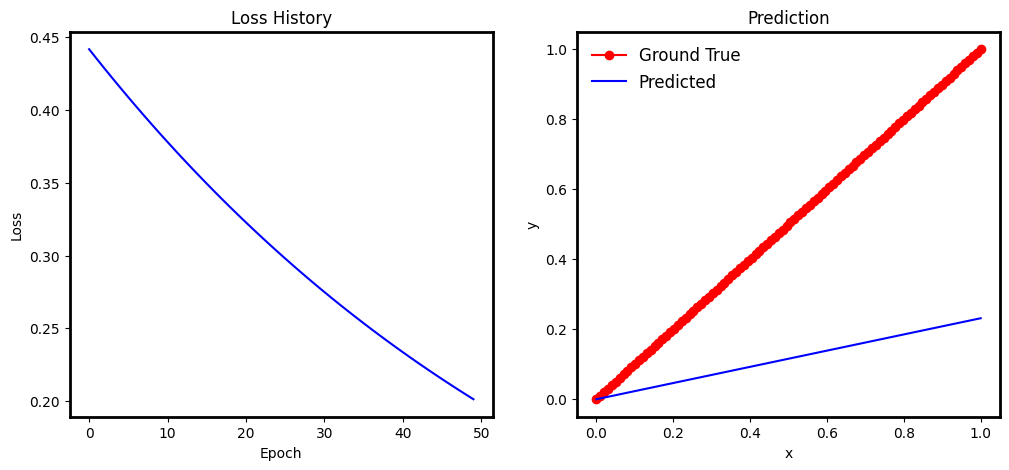

In [11]:
class DenseModel(nn.Module):
    def __init__(self):
        super(DenseModel, self).__init__()
        self.W_xh1 = nn.Linear(1, 1, bias=False)
        self.W_h1h2 = nn.Linear(2, 1, bias=False)
        self.W_h2h3 = nn.Linear(3, 1, bias=False)
        self.W_h3h4 = nn.Linear(4, 1, bias=False)
        self.W_h4y = nn.Linear(5, 1, bias=False)

    
    def forward(self, x):
        h1 = F.relu(self.W_xh1(x))
        h1_cat = torch.cat((x, h1), dim=1)

        h2 = F.relu(self.W_h1h2(h1_cat))
        h2_cat = torch.cat((x, h1, h2), dim=1)

        h3 = F.relu(self.W_h2h3(h2_cat))
        h3_cat = torch.cat((x, h1, h2, h3), dim=1)

        h4 = F.relu(self.W_h3h4(h3_cat))
        h4_cat = torch.cat((x, h1, h2, h3, h4), dim=1)
        
        y = self.W_h4y(h4_cat)
        return y


x_np =  np.linspace(0, 1, 100)
y_np = np.linspace(0, 1, 100)
x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)

model = DenseModel()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 50
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad();y_pred = model(x);loss = F.mse_loss(y_pred, y);loss_history.append(loss.item());loss.backward();optimizer.step()
    if epoch % 10 == 0: print(f'Epoch {epoch}, Loss: {loss.item()}')

with torch.no_grad(): y_pred = model(x)

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].plot(loss_history, color='blue')
ax[0].set_title('Loss History')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')

ax[1].plot(x_np, y_np, 'o-', color='red', label = "Ground True")
ax[1].plot(x_np, y_pred.detach().numpy(), 'b-', label = "Predicted")
ax[1].set_title('Prediction')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].legend(frameon=False, fontsize= 12)

for ax in fig.axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.show()

## 34-layer ResNet

In [12]:
class Resolution_Preserving_block(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(Resolution_Preserving_block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += x
        out = F.relu(out)
        return out


class Resolution_reducing_block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Resolution_reducing_block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv_for_input = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=2)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.conv_for_input(x)
        out = F.relu(out)
        return out


class ResNet34(nn.Module):
    
    def __init__(self, num_classes):
        super(ResNet34, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = nn.Sequential(
            Resolution_Preserving_block(64, 64),
            Resolution_Preserving_block(64, 64),
            Resolution_Preserving_block(64, 64),
        )

        self.layer2 = nn.Sequential(
            Resolution_reducing_block(64, 128),
            Resolution_Preserving_block(128, 128),
            Resolution_Preserving_block(128, 128),
            Resolution_Preserving_block(128, 128),
        )

        self.layer3 = nn.Sequential(
            Resolution_reducing_block(128, 256),
            Resolution_Preserving_block(256, 256),
            Resolution_Preserving_block(256, 256),
            Resolution_Preserving_block(256, 256),
            Resolution_Preserving_block(256, 256),
            Resolution_Preserving_block(256, 256),
        )

        self.layer4 = nn.Sequential(
            Resolution_reducing_block(256, 512),
            Resolution_Preserving_block(512, 512),
            Resolution_Preserving_block(512, 512)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):

        # Step 1: (3, 224, 224) -> (64, 112, 112)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Step 2: (64, 112, 112) -> (64, 112, 112)
        x = self.layer1(x)

        # Step 3: (64, 112, 112) -> (128, 56, 56)
        x = self.layer2(x)

        # Step 4: (128, 56, 56) -> (256, 28, 28)
        x = self.layer3(x)

        # Step 5: (256, 28, 28) -> (512, 14, 14)
        x = self.layer4(x)

        # Step 6: (512, 14, 14) -> (512, 1, 1)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = F.softmax(x, dim=1)
        return x

## DenseNet-121

In [13]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)
    
    def forward(self, x):
        out = self.bn(x)
        out = self.relu(out)
        out = self.conv(out)
        out = torch.cat([x, out], 1)
        return out

class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, num_layers):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layers(x)

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        out = self.bn(x)
        out = self.relu(out)
        out = self.conv(out)
        out = self.pool(out)
        return out

class DenseNet121(nn.Module):
    def __init__(self, growth_rate=32, num_classes=1000, compression=0.5):
        super(DenseNet121, self).__init__()

        # Initial conv
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Dense blocks configuration
        self.growth_rate = growth_rate
        block_layers = [6, 12, 24, 16]
        num_channels = 64

        # DenseBlock1
        self.dense_block1 = DenseBlock(num_channels, growth_rate, block_layers[0])
        num_channels += block_layers[0] * growth_rate
        out_channels = int(num_channels * compression)
        self.transition1 = TransitionLayer(num_channels, out_channels)
        num_channels = out_channels

        # DenseBlock2
        self.dense_block2 = DenseBlock(num_channels, growth_rate, block_layers[1])
        num_channels += block_layers[1] * growth_rate
        out_channels = int(num_channels * compression)
        self.transition2 = TransitionLayer(num_channels, out_channels)
        num_channels = out_channels

        # DenseBlock3
        self.dense_block3 = DenseBlock(num_channels, growth_rate, block_layers[2])
        num_channels += block_layers[2] * growth_rate
        out_channels = int(num_channels * compression)
        self.transition3 = TransitionLayer(num_channels, out_channels)
        num_channels = out_channels

        # DenseBlock4
        self.dense_block4 = DenseBlock(num_channels, growth_rate, block_layers[3])
        num_channels += block_layers[3] * growth_rate

        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(num_channels, num_classes)

    def forward(self, x):
        
        # Step 1 (3 244 244) -> (64 56 56)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.pool1(out)

        # Step 2 (64 56 56) -> (64 28 28)
        out = self.dense_block1(out)
        out = self.transition1(out)

        # Step 3 (64 28 28) -> (64 14 14)
        out = self.dense_block2(out)
        out = self.transition2(out)

        # Step 4 (64 14 14) -> (64 7 7)
        out = self.dense_block3(out)
        out = self.transition3(out)

        # Step 5 (64 7 7) -> (64 7 7)
        out = self.dense_block4(out)

        # Step 6 (64 7 7) -> (classes)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [14]:
from torch.utils.data import DataLoader, Subset
import random
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],  # CIFAR-10 mean
        std=[0.2023, 0.1994, 0.2010]    # CIFAR-10 std
    ),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    ),
])

# -----------------------------
# 2. Dataset
# -----------------------------
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# -----------------------------
# 3. Dataset 일부만 사용 (옵션, 학습 테스트용)
# -----------------------------
train_dataset = Subset(train_dataset, random.sample(range(len(train_dataset)), 5000))
test_dataset = Subset(test_dataset, random.sample(range(len(test_dataset)), 1000))

# -----------------------------
# 4. DataLoader
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# -----------------------------
# 5. Model
# -----------------------------
num_classes = 10
model = ResNet34(num_classes=num_classes)


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


epochs = 10  # 테스트용
ResNet_history = {}
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    
    train_loss = running_loss / total
    train_acc = 100. * correct / total
    
    # -----------------------------
    # 검증
    # -----------------------------
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()
    
    test_acc = 100. * correct_test / total_test
    
    ResNet_history[epoch] = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_acc': test_acc
    }
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")


Epoch [1/10] Train Loss: 2.2671 Train Acc: 18.60% Test Acc: 19.10%
Epoch [2/10] Train Loss: 2.2534 Train Acc: 20.34% Test Acc: 19.90%
Epoch [3/10] Train Loss: 2.2356 Train Acc: 21.80% Test Acc: 23.60%
Epoch [4/10] Train Loss: 2.2061 Train Acc: 24.68% Test Acc: 25.70%
Epoch [5/10] Train Loss: 2.1900 Train Acc: 26.30% Test Acc: 28.10%
Epoch [6/10] Train Loss: 2.1827 Train Acc: 27.40% Test Acc: 28.70%
Epoch [7/10] Train Loss: 2.1519 Train Acc: 30.22% Test Acc: 29.50%
Epoch [8/10] Train Loss: 2.1679 Train Acc: 28.32% Test Acc: 30.00%
Epoch [9/10] Train Loss: 2.1635 Train Acc: 29.00% Test Acc: 26.50%
Epoch [10/10] Train Loss: 2.1602 Train Acc: 29.34% Test Acc: 32.20%


In [15]:
num_classes = 10
model = DenseNet121(num_classes=num_classes)


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


epochs = 10  # 테스트용

DenseNet_history = {}
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    scheduler.step()
    
    train_loss = running_loss / total
    train_acc = 100. * correct / total
    
    # -----------------------------
    # 검증
    # -----------------------------
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()
    
    test_acc = 100. * correct_test / total_test
    
    DenseNet_history[epoch] = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_acc': test_acc
    }
    
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")


Epoch [1/10] Train Loss: 1.8788 Train Acc: 30.40% Test Acc: 36.40%
Epoch [2/10] Train Loss: 1.5911 Train Acc: 41.98% Test Acc: 42.70%
Epoch [3/10] Train Loss: 1.4781 Train Acc: 46.16% Test Acc: 44.40%
Epoch [4/10] Train Loss: 1.3657 Train Acc: 50.60% Test Acc: 46.60%
Epoch [5/10] Train Loss: 1.2737 Train Acc: 53.62% Test Acc: 51.90%
Epoch [6/10] Train Loss: 1.2121 Train Acc: 56.22% Test Acc: 50.50%
Epoch [7/10] Train Loss: 1.1458 Train Acc: 59.04% Test Acc: 50.10%
Epoch [8/10] Train Loss: 1.1081 Train Acc: 60.30% Test Acc: 57.90%
Epoch [9/10] Train Loss: 1.0341 Train Acc: 63.62% Test Acc: 57.30%
Epoch [10/10] Train Loss: 0.9748 Train Acc: 65.10% Test Acc: 57.80%


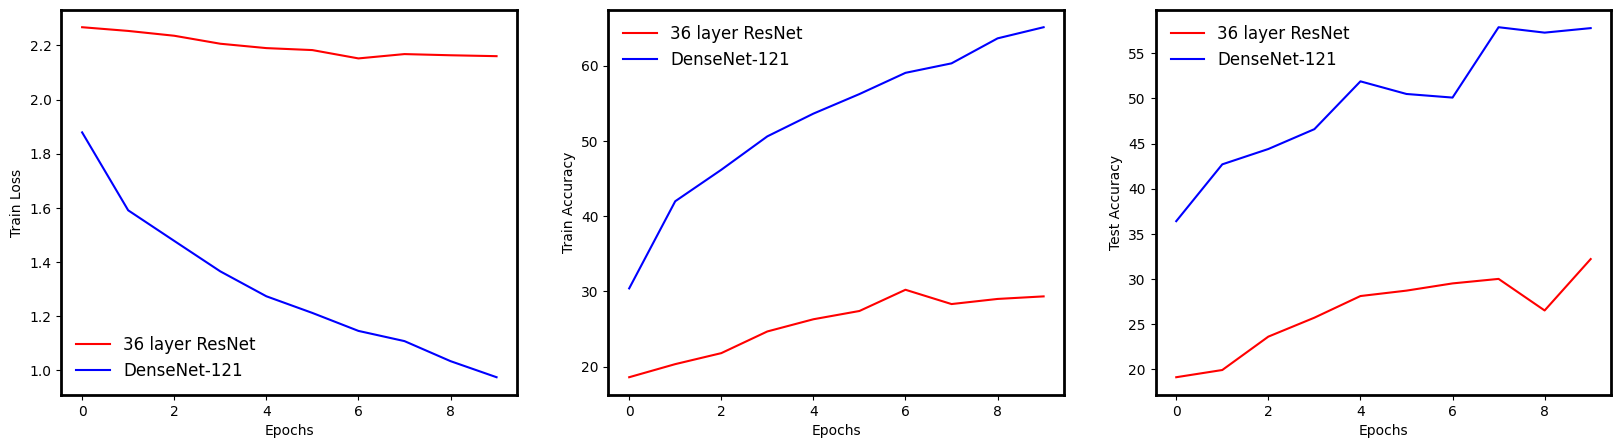

In [ ]:
fig, ax = plt.subplots(1, 3, figsize = (20, 5))



ax[0].plot([i for i in range(epochs)],[ResNet_history[i]['train_loss'] for i in range(epochs)], color= 'red', label = "36 layer ResNet")
ax[0].plot([i for i in range(epochs)],[DenseNet_history[i]['train_loss'] for i in range(epochs)], color='blue', label = "DenseNet-121")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Train Loss")
ax[0].legend(frameon = False, fontsize = 12)

ax[1].plot([i for i in range(epochs)],[ResNet_history[i]['train_acc'] for i in range(epochs)], color= 'red', label = "36 layer ResNet")
ax[1].plot([i for i in range(epochs)],[DenseNet_history[i]['train_acc'] for i in range(epochs)], color='blue', label = "DenseNet-121")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Train Accuracy (%)")
ax[1].legend(frameon = False, fontsize = 12)

ax[2].plot([i for i in range(epochs)],[ResNet_history[i]['test_acc'] for i in range(epochs)], color= 'red', label = "36 layer ResNet")
ax[2].plot([i for i in range(epochs)],[DenseNet_history[i]['test_acc'] for i in range(epochs)], color='blue', label = "DenseNet-121")
ax[2].set_xlabel("Epochs")
ax[2].set_ylabel("Test Accuracy (%)")
ax[2].legend(frameon = False, fontsize = 12)

for ax in [ax[0], ax[1], ax[2]]:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
plt.show()